In [1]:
import pandas as pd

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

print(orders.shape)
print(customers.shape)
orders.head()

(99441, 8)
(99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
# 1. How many orders in each status?
print(orders["order_status"].value_counts())

# 2. Any missing values in the date we care about?
print(orders["order_purchase_timestamp"].isnull().sum())

# 3. Date range of the data
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
print(orders["order_purchase_timestamp"].min())
print(orders["order_purchase_timestamp"].max())

# 4. Real people vs customer_id
print(customers["customer_id"].nunique())
print(customers["customer_unique_id"].nunique())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
0
2016-09-04 21:15:19
2018-10-17 17:30:18
99441
96096


In [3]:
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

# 1. Keep only delivered orders
delivered = orders[orders["order_status"] == "delivered"]

# 2. Total payment for each order
order_total = payments.groupby("order_id")["payment_value"].sum().reset_index()

# 3. Join the tables together
sales = delivered.merge(customers, on="customer_id")
sales = sales.merge(order_total, on="order_id")

# 4. Keep only the columns we need
sales = sales[["order_id", "customer_unique_id", "order_purchase_timestamp", "payment_value"]]

print(sales.shape)
sales.head()

(96477, 4)


,order_id,customer_unique_id,order_purchase_timestamp,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,28.62


In [4]:
# 1. Make sure the date column is a real date
sales["order_purchase_timestamp"] = pd.to_datetime(sales["order_purchase_timestamp"])

# 2. Create our "today" date
snapshot_date = sales["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# 3. Calculate R, F, M for each customer
rfm = sales.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("payment_value", "sum")
).reset_index()

print(rfm.shape)
rfm.head()

(93357, 4)


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [5]:
# Recency: fewer days = better, so the smallest days get score 5
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: scored by hand because most customers bought only once
rfm["F_score"] = pd.cut(rfm["Frequency"], bins=[0, 1, 2, 3, 4, float("inf")], labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: more money = better, so the biggest spenders get score 5
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [6]:
import numpy as np

# The rules, in order (the first rule that matches wins)
conditions = [
    (rfm["R_score"] >= 4) & (rfm["F_score"] >= 2),
    (rfm["F_score"] >= 2),
    (rfm["R_score"] >= 4),
    (rfm["R_score"] <= 2) & (rfm["M_score"] >= 4),
    (rfm["R_score"] <= 2),
]

# The names that match each rule
names = ["Champions", "Loyal Customers", "New Customers", "At Risk", "Lost Customers"]

# Apply the rules; anyone who matches nothing is "Needs Attention"
rfm["Segment"] = np.select(conditions, names, default="Needs Attention")

# Count customers in each segment
print(rfm["Segment"].value_counts())

# Average R, F, M of each segment
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(1)

Segment
New Customers      36224
Lost Customers     22488
Needs Attention    18105
At Risk            13739
Loyal Customers     1592
Champions           1209
Name: count, dtype: int64


,Recency,Frequency,Monetary
Segment,,,
At Risk,394.2,1.0,307.9
Champions,89.2,2.2,322.2
Lost Customers,396.1,1.0,72.7
Loyal Customers,319.9,2.1,298.2
Needs Attention,220.5,1.0,151.3
New Customers,90.6,1.0,164.3


In [7]:
import os

# 1. Make a folder for the finished data (if it does not exist)
os.makedirs("../data/processed", exist_ok=True)

# 2. Save the RFM table
rfm.to_csv("../data/processed/rfm_segments.csv", index=False)

print("Saved! Rows:", len(rfm))

Saved! Rows: 93357


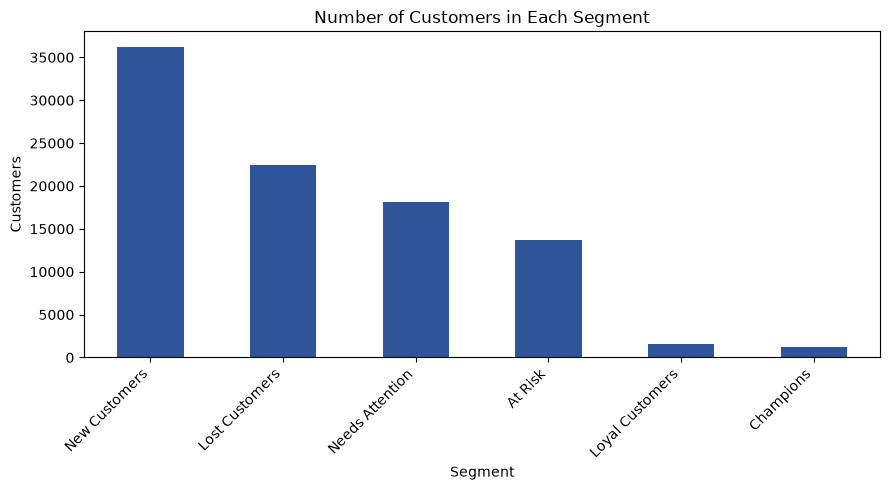

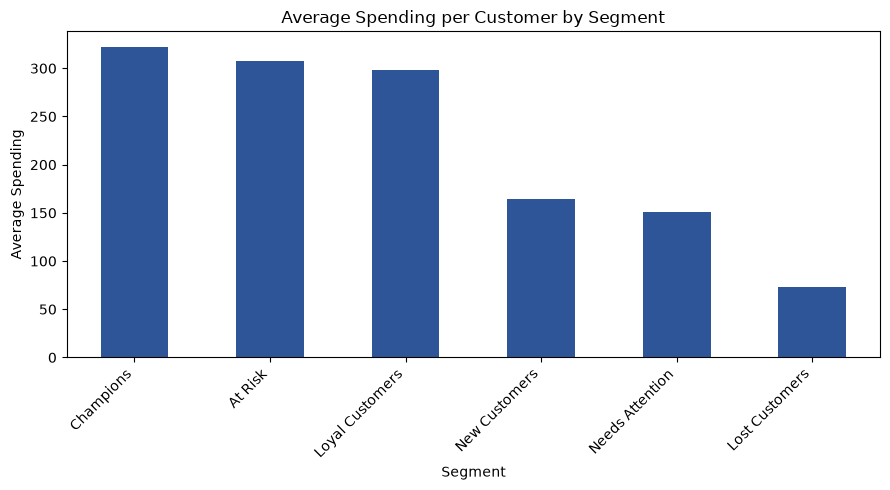

In [8]:
import matplotlib.pyplot as plt

# Make a folder for the charts
os.makedirs("../docs/charts", exist_ok=True)

# Chart 1: number of customers in each segment
counts = rfm["Segment"].value_counts()
plt.figure(figsize=(9, 5))
counts.plot(kind="bar", color="#2E5597")
plt.title("Number of Customers in Each Segment")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../docs/charts/segment_sizes.png", dpi=150)
plt.show()

# Chart 2: average money spent per customer in each segment
avg_money = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
avg_money.plot(kind="bar", color="#2E5597")
plt.title("Average Spending per Customer by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../docs/charts/segment_spending.png", dpi=150)
plt.show()

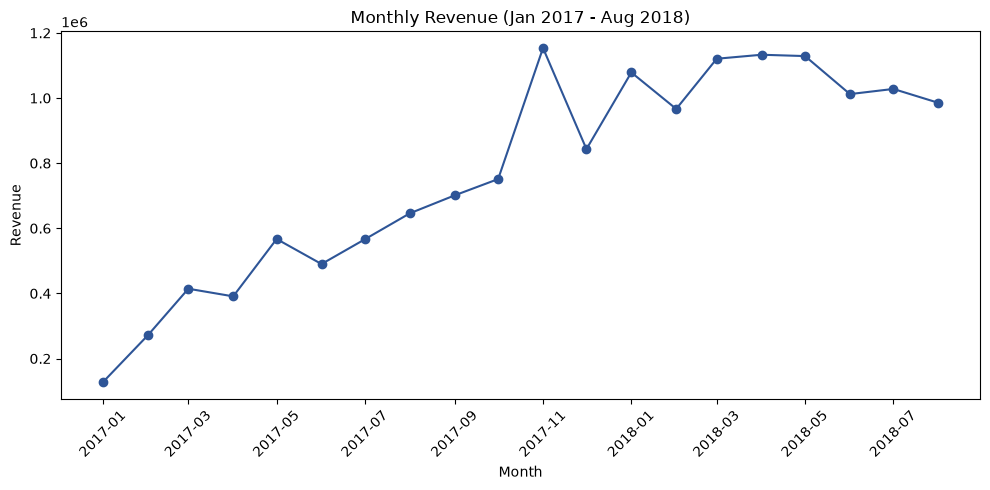

(20, 3)


,month,Revenue,Orders
2,2017-01-01,127545.67,750
3,2017-02-01,271298.65,1653
4,2017-03-01,414369.39,2546
5,2017-04-01,390952.18,2303
6,2017-05-01,567066.73,3546


In [9]:
# 1. Make a column with the month of each order
sales["month"] = sales["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# 2. Add up revenue and count orders for each month
monthly = sales.groupby("month").agg(
    Revenue=("payment_value", "sum"),
    Orders=("order_id", "nunique")
).reset_index()

# 3. Keep only the complete months
monthly = monthly[(monthly["month"] >= "2017-01-01") & (monthly["month"] <= "2018-08-01")]

# 4. Save the table
monthly.to_csv("../data/processed/monthly_sales.csv", index=False)

# 5. Draw the trend
plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["Revenue"], marker="o", color="#2E5597")
plt.title("Monthly Revenue (Jan 2017 - Aug 2018)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/charts/monthly_revenue.png", dpi=150)
plt.show()

print(monthly.shape)
monthly.head()

In [10]:
# 1. Get the revenue numbers as a simple list
revenue = monthly["Revenue"].values

# 2. Hide the last 3 months: train = past, test = hidden months
train = revenue[:-3]
test = revenue[-3:]

# 3. Method 1: average of the last 3 months
baseline = np.repeat(train[-3:].mean(), 3)

# 4. Method 2: straight line through all months
x = np.arange(len(train))
future_x = np.arange(len(train), len(train) + 3)
line_all = np.polyval(np.polyfit(x, train, 1), future_x)

# 5. Method 3: straight line through the last 6 months only
line_6 = np.polyval(np.polyfit(x[-6:], train[-6:], 1), future_x)

# 6. Measure the mistake (MAPE) of each method
def mape(real, predicted):
    return np.mean(np.abs(real - predicted) / real) * 100

print("Real values   :", test.round(0))
print("Baseline MAPE :", round(mape(test, baseline), 1), "%")
print("Line (all)    :", round(mape(test, line_all), 1), "%")
print("Line (last 6) :", round(mape(test, line_6), 1), "%")

Real values   : [1012091. 1027904.  985414.]
Baseline MAPE : 11.8 %
Line (all)    : 34.2 %
Line (last 6) : 26.0 %


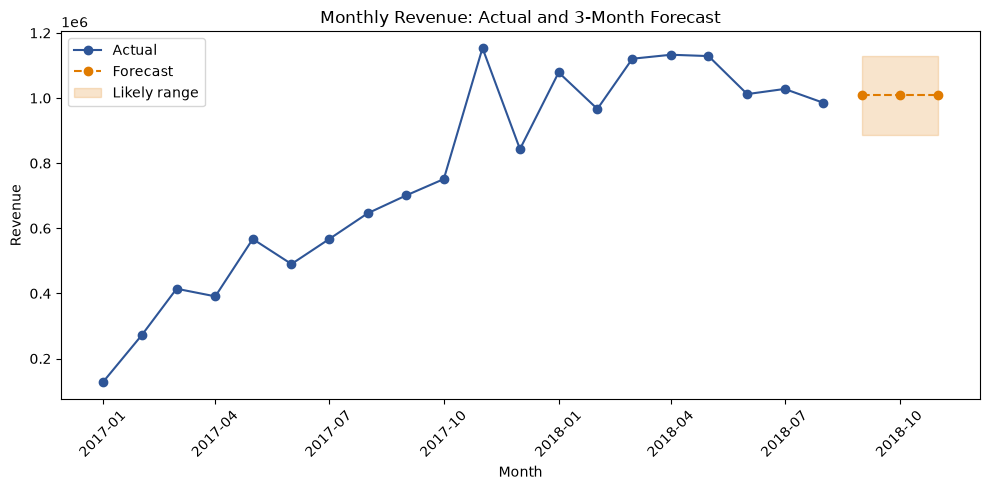

C:\Users\Pak\AppData\Local\Temp\ipykernel_2648\4083984283.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  forecast.round(0)


,month,Forecast,Low,High
0,2018-09-01,1008470.0,887453.0,1129486.0
1,2018-10-01,1008470.0,887453.0,1129486.0
2,2018-11-01,1008470.0,887453.0,1129486.0


In [11]:
# 1. The forecast value: average of the last 3 months
forecast_value = revenue[-3:].mean()

# 2. The next 3 months
future_months = pd.date_range(monthly["month"].max() + pd.DateOffset(months=1), periods=3, freq="MS")

# 3. Likely range, using the 12% error from our backtest
error = 0.12
forecast = pd.DataFrame({
    "month": future_months,
    "Forecast": forecast_value,
    "Low": forecast_value * (1 - error),
    "High": forecast_value * (1 + error)
})

# 4. Save the forecast
forecast.to_csv("../data/processed/revenue_forecast.csv", index=False)

# 5. Draw actual sales and forecast together
plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["Revenue"], marker="o", color="#2E5597", label="Actual")
plt.plot(forecast["month"], forecast["Forecast"], marker="o", linestyle="--", color="#E07B00", label="Forecast")
plt.fill_between(forecast["month"], forecast["Low"], forecast["High"], color="#E07B00", alpha=0.2, label="Likely range")
plt.title("Monthly Revenue: Actual and 3-Month Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../docs/charts/revenue_forecast.png", dpi=150)
plt.show()

forecast.round(0)

In [12]:
# 1. Actual sales: rename Revenue to Actual
actual = monthly[["month", "Revenue"]].rename(columns={"Revenue": "Actual"})

# 2. Stack actual sales and forecast into one table
trend = pd.concat([actual, forecast], ignore_index=True)

# 3. Connect the two lines on the chart
last = trend["Actual"].last_valid_index()
trend.loc[last, "Forecast"] = trend.loc[last, "Actual"]

# 4. Save the table
trend.to_csv("../data/processed/revenue_trend.csv", index=False)

print(trend.shape)
trend.tail(6)

(23, 5)


,month,Actual,Forecast,Low,High
17,2018-06-01,1012090.68,NaN,NaN,NaN
18,2018-07-01,1027903.86,NaN,NaN,NaN
19,2018-08-01,985414.28,9.854143e+05,NaN,NaN
20,2018-09-01,NaN,1.008470e+06,887453.253867,1.129486e+06
21,2018-10-01,NaN,1.008470e+06,887453.253867,1.129486e+06
22,2018-11-01,NaN,1.008470e+06,887453.253867,1.129486e+06
